<a href="https://colab.research.google.com/github/analissahaga/owid-co2-feature-selection/blob/main/CO2shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

print(df.shape)


(50411, 79)


In [3]:
"""
Pipeline SHAP Feature Selection — estilo Marcílio & Eler (2020)
Dataset: OWID CO2 (carregado diretamente do GitHub)
"""

import time
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import (
    f_classif, f_regression,
    mutual_info_classif, mutual_info_regression,
    RFE
)
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')


In [4]:
def load_owid_co2():
    """Carrega OWID CO2 direto do GitHub."""
    url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
    df = pd.read_csv(url)
    print(f"Dataset bruto: {df.shape}")
    return df


In [5]:
def preprocess_regression(df, year_min=2000, target='co2_per_capita'):
    """
    Prepara dados para regressão.
    Alvo: co2_per_capita (contínuo)
    """
    df = df[df['year'] >= year_min].copy()
    df = df.dropna(subset=[target])

    exclude = ['country', 'year', 'iso_code', target]
    feature_cols = [
        c for c in df.select_dtypes(include='number').columns
        if c not in exclude
    ]

    X = df[feature_cols].values
    y = df[target].values

    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(X)

    return X, y, feature_cols


def preprocess_classification(df, year_min=2000, target='co2_per_capita', n_classes=3):
    """
    Prepara dados para classificação.
    Discretiza co2_per_capita em n_classes (tercis/quartis).
    """
    df = df[df['year'] >= year_min].copy()
    df = df.dropna(subset=[target])

    # Discretizar em classes balanceadas
    df['class'] = pd.qcut(df[target], q=n_classes, labels=range(n_classes))
    df = df.dropna(subset=['class'])

    exclude = ['country', 'year', 'iso_code', target, 'class']
    feature_cols = [
        c for c in df.select_dtypes(include='number').columns
        if c not in exclude
    ]

    X = df[feature_cols].values
    y = df['class'].astype(int).values

    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(X)

    return X, y, feature_cols


In [6]:
def select_features_anova(X, y, task='classification'):
    """ANOVA-F univariado."""
    if task == 'classification':
        scores, _ = f_classif(X, y)
    else:
        scores, _ = f_regression(X, y)
    return np.argsort(scores)[::-1]


def select_features_mi(X, y, task='classification', random_state=42):
    """Mutual Information univariado."""
    if task == 'classification':
        scores = mutual_info_classif(X, y, random_state=random_state)
    else:
        scores = mutual_info_regression(X, y, random_state=random_state)
    return np.argsort(scores)[::-1]


def select_features_shap(X, y, task='classification', feature_names=None):
    """
    SHAP: treina XGBoost no conjunto completo e extrai importância
    pela média dos valores absolutos (como no artigo).
    """
    if task == 'classification':
        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
    else:
        model = xgb.XGBRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )

    model.fit(X, y)
    explainer = shap.TreeExplainer(model)

    if task == 'classification':
        shap_values = explainer.shap_values(X)
        # shap_values é lista (uma matriz por classe); média entre classes
        importance = np.mean([
            np.abs(sv).mean(axis=0) for sv in shap_values
        ], axis=0)
    else:
        shap_values = explainer.shap_values(X)
        importance = np.abs(shap_values).mean(axis=0)

    return np.argsort(importance)[::-1]


def select_features_rfe(X, y, task='classification', n_features_to_select=10, step=0.1):
    """
    RFE: eliminação recursiva de features.
    """
    if task == 'classification':
        estimator = xgb.XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
        )
    else:
        estimator = xgb.XGBRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
        )

    start = time.time()
    rfe = RFE(
        estimator=estimator,
        n_features_to_select=n_features_to_select,
        step=step
    )
    rfe.fit(X, y)
    elapsed = time.time() - start
    print(f"RFE concluído em {elapsed:.2f}s")

    # ranking_: 1 = selecionada, 2 = eliminada na última iteração, etc.
    return np.argsort(rfe.ranking_)[::-1]


In [7]:
def keep_absolute_metric(X, y, ranking, model_template, percentages, task='classification', cv=5):
    """
    Implementa o Keep Absolute metric do artigo:
    - mantém d% das features mais importantes
    - mascara as demais com a média da coluna
    - re-treina e avalia
    - retorna curva de scores
    """
    scores = []
    n_features = X.shape[1]

    for pct in percentages:
        k = max(1, int(n_features * pct / 100))
        top_k = ranking[:k]

        # Criar cópia e mascarar features não selecionadas
        X_masked = X.copy()
        mask = np.ones(n_features, dtype=bool)
        mask[top_k] = False
        X_masked[:, mask] = np.mean(X[:, mask], axis=0) if np.any(mask) else 0

        # Avaliar com cross-validation
        if task == 'classification':
            y_pred = cross_val_predict(
                model_template, X_masked, y, cv=cv, method='predict'
            )
            y_proba = cross_val_predict(
                model_template, X_masked, y, cv=cv, method='predict_proba'
            )

            score = f1_score(y, y_pred, average='macro')
        else:
            y_pred = cross_val_predict(model_template, X_masked, y, cv=cv)
            score = -mean_squared_error(y, y_pred)  # negativo, como no artigo

        scores.append(score)

    return scores


In [8]:
def get_model(task='classification'):
    if task == 'classification':
        return xgb.XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
    else:
        return xgb.XGBRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )


In [9]:
def run_regression_pipeline():
    print("=" * 60)
    print("PIPELINE DE REGRESSÃO — co2_per_capita")
    print("=" * 60)

    df = load_owid_co2()
    X, y, feature_names = preprocess_regression(df, year_min=2020)

    print(f"Dados finais: {X.shape}")

    model = get_model('regression')
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Ranking dos 4 métodos
    print("\nCalculando rankings...")
    rank_anova = select_features_anova(X, y, task='regression')
    rank_mi = select_features_mi(X, y, task='regression')
    rank_shap = select_features_shap(X, y, task='regression', feature_names=feature_names)
    rank_rfe = select_features_rfe(X, y, task='regression',
                                   n_features_to_select=10, step=0.1)

    methods = {
        'TreeSHAP': rank_shap,
        'ANOVA': rank_anova,
        'Mutual Information': rank_mi,
        'RFE': rank_rfe
    }

    percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    print("\nAplicando Keep Absolute...")
    results = {}
    for name, ranking in methods.items():
        print(f"  - {name}")
        scores = keep_absolute_metric(
            X, y, ranking, model, percentages,
            task='regression', cv=cv
        )
        results[name] = scores

    # AUC das curvas (como Tabela III do artigo)
    from sklearn.metrics import auc

    print("\n" + "=" * 60)
    print("AUC DAS CURVAS (quanto mais próximo de zero, melhor)")
    print("=" * 60)
    for name, scores in results.items():
        auc_score = auc(percentages, scores)
        print(f"{name:<22} {auc_score:>12.4f}")

    # Plot
    plt.figure(figsize=(10, 6))
    for name, scores in results.items():
        plt.plot(percentages, scores, marker='o', label=name)
    plt.xlabel('% de features mantidas')
    plt.ylabel('Neg. Mean Squared Error')
    plt.title('Keep Absolute — Regressão OWID CO2 (2020)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('keep_absolute_regression.png', dpi=300)
    plt.show()

    return results


In [10]:
def run_classification_pipeline():
    print("=" * 60)
    print("PIPELINE DE CLASSIFICAÇÃO — co2_per_capita (3 classes)")
    print("=" * 60)

    df = load_owid_co2()
    X, y, feature_names = preprocess_classification(df, year_min=2020, n_classes=3)

    print(f"Dados finais: {X.shape}")

    model = get_model('classification')
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    print("\nCalculando rankings...")
    rank_anova = select_features_anova(X, y, task='classification')
    rank_mi = select_features_mi(X, y, task='classification')
    rank_shap = select_features_shap(X, y, task='classification', feature_names=feature_names)
    rank_rfe = select_features_rfe(X, y, task='classification',
                                   n_features_to_select=10, step=0.1)

    methods = {
        'TreeSHAP': rank_shap,
        'ANOVA': rank_anova,
        'Mutual Information': rank_mi,
        'RFE': rank_rfe
    }

    percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    print("\nAplicando Keep Absolute...")
    results = {}
    for name, ranking in methods.items():
        print(f"  - {name}")
        scores = keep_absolute_metric(
            X, y, ranking, model, percentages,
            task='classification', cv=cv
        )
        results[name] = scores

    # AUC das curvas (como Tabela II do artigo)
    from sklearn.metrics import auc

    print("\n" + "=" * 60)
    print("AUC DAS CURVAS F1-macro")
    print("=" * 60)
    for name, scores in results.items():
        auc_score = auc(percentages, scores)
        print(f"{name:<22} {auc_score:>12.4f}")

    # Plot
    plt.figure(figsize=(10, 6))
    for name, scores in results.items():
        plt.plot(percentages, scores, marker='o', label=name)
    plt.xlabel('% de features mantidas')
    plt.ylabel('F1-score macro')
    plt.title('Keep Absolute — Classificação OWID CO2 (2020)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('keep_absolute_classification.png', dpi=300)
    plt.show()

    return results


PIPELINE DE REGRESSÃO — co2_per_capita
Dataset bruto: (50411, 79)
Dados finais: (1155, 75)

Calculando rankings...
RFE concluído em 5.38s

Aplicando Keep Absolute...
  - TreeSHAP
  - ANOVA
  - Mutual Information
  - RFE

AUC DAS CURVAS (quanto mais próximo de zero, melhor)
TreeSHAP                   -10.4124
ANOVA                      -12.6147
Mutual Information         -12.1245
RFE                       -155.2046


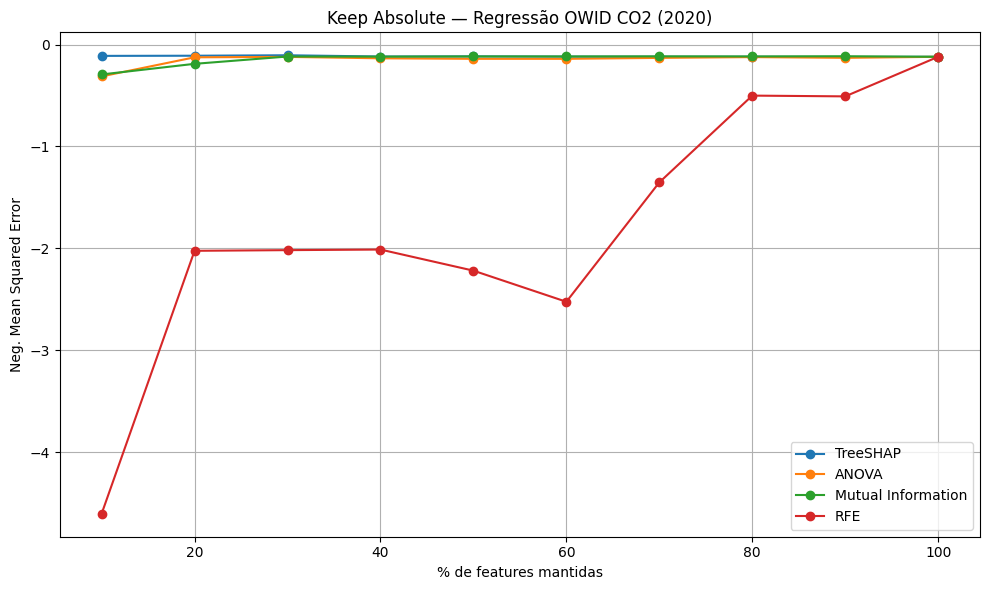

In [11]:
if __name__ == '__main__':
    # Escolha um dos dois:
    results_reg = run_regression_pipeline()
    # results_clf = run_classification_pipeline()


PIPELINE DE CLASSIFICAÇÃO — co2_per_capita (3 classes)
Dataset bruto: (50411, 79)
Dados finais: (1155, 75)

Calculando rankings...
RFE concluído em 8.34s

Aplicando Keep Absolute...
  - TreeSHAP
  - ANOVA
  - Mutual Information
  - RFE

AUC DAS CURVAS F1-macro
TreeSHAP                    72.2223
ANOVA                       88.2425
Mutual Information          88.2342
RFE                         85.1554


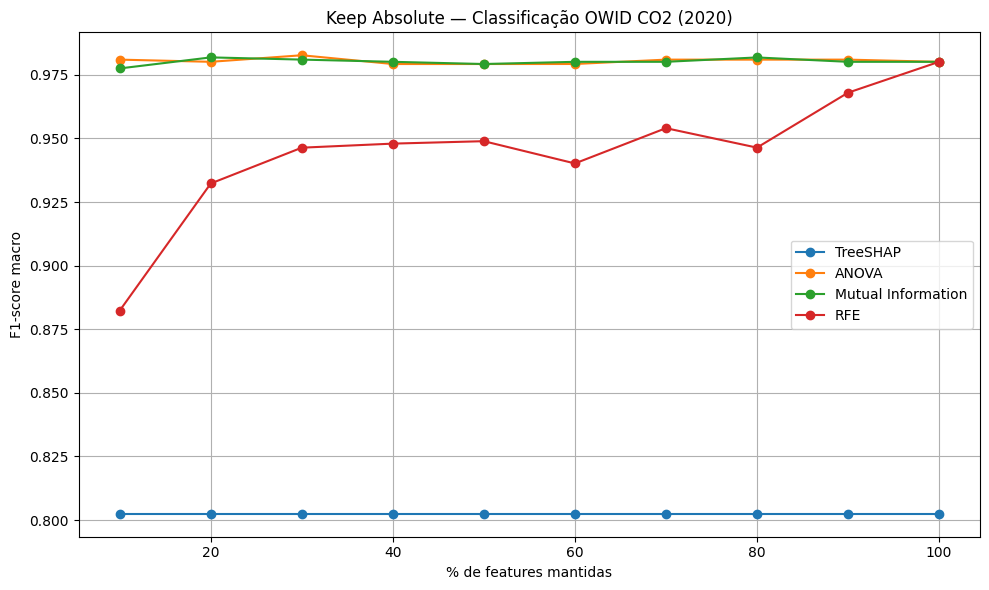

In [12]:
if __name__ == '__main__':
    # Escolha um dos dois:
    #results_reg = run_regression_pipeline()
    results_clf = run_classification_pipeline()
